# SIRS ≥2 duration around suspected infection

This notebook estimates sustained SIRS ≥2 intervals around canonical suspected-infection episodes using the current `src_strategy` outputs. It replaces the start-time-only and observed-row-span logic in notebook 17.

Important interpretation:

- The approved clinical definition requires suspected infection plus SIRS score ≥2; it does **not** currently specify a minimum SIRS duration. Duration thresholds below are sensitivity analyses, not approved clinical rules.
- SIRS intervals are reconstructed from measurement timestamps and configured validity periods. They are not inferred from gaps between unrelated backbone rows.
- Paired infection evidence is reduced to one configurable anchor. The default is the earliest evidence timestamp (`min(evidence timestamps)`), representing when the clinician first suspected infection. Completion time remains available only as a sensitivity analysis.
- The notebook never displays or exports encounter-level rows. Clear all outputs before sharing or committing after execution.


In [15]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src_strategy.configs.aggregator import FEATURE_REGISTRY
from src_strategy.configs.dataconfig import input_output_config_3_1
from src_strategy.configs.sirscalculator import sirs_config
from src_strategy.configs.suspected_infection import suspected_infection_config
from src_strategy.events.sirs import build_sirs_pipeline
from src_strategy.events.suspected_infection import build_suspected_infection_pipeline

sns.set_theme(style="whitegrid")


## Analysis configuration

The SIRS association window comes from the current severity configuration (currently 24 hours before and after infection). `PAIR_ANCHOR_POLICY` defaults to `"earliest_evidence"` because the anchor represents the first clinician-suspicion timestamp. It can be changed to `"criterion_completion"` for a separately reported sensitivity analysis.


In [16]:
ENCOUNTER_COL = sirs_config.encounter_col
EVENT_DT_COL = sirs_config.event_dt_col
SIRS_SCORE_COL = sirs_config.sirs_score_col
SIRS_SCORE_THRESHOLD = 2

INFECTION_DT_COL = suspected_infection_config.value_name_dt_col
INFECTION_TYPE_COL = suspected_infection_config.value_type_col
INFECTION_CRITERION_COL = suspected_infection_config.variable_name_col

# Mirrors src_strategy/configs/severitysepsis.py. Kept explicit because importing
# that module currently traverses an unrelated incomplete organ-dysfunction config.
WINDOW_BEFORE_HOURS = 24.0
WINDOW_AFTER_HOURS = 24.0
PAIR_ANCHOR_POLICY = "earliest_evidence"  # optional sensitivity analysis: criterion_completion
CANDIDATE_DURATION_HOURS = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 6.0, 8.0]

OUTPUT_DIR = Path(input_output_config_3_1.output_path)
SIRS_PATH = OUTPUT_DIR / "df_sirs.parquet"
AGGREGATED_PATH = OUTPUT_DIR / "df_aggregated.parquet"
INFECTION_PATH = OUTPUT_DIR / "df_suspected_infection.parquet"
EVENT_PATH = OUTPUT_DIR / "df_all_no_collisions.parquet"

assert PAIR_ANCHOR_POLICY in {"criterion_completion", "earliest_evidence"}


In [17]:
@dataclass(frozen=True)
class SIRSFeatureSpec:
    value_col: str
    source_ts_col: str
    validity_minutes: int


def feature_spec(feature_column) -> SIRSFeatureSpec:
    definition = FEATURE_REGISTRY[feature_column]
    if definition.lookback_period is None:
        raise ValueError(f"SIRS feature {feature_column.value} needs a validity period")
    return SIRSFeatureSpec(
        value_col=feature_column.value,
        source_ts_col=f"{feature_column.value}_source_ts",
        validity_minutes=int(definition.lookback_period),
    )


SIRS_FEATURE_SPECS = [
    feature_spec(sirs_config.temp_feature_col),
    feature_spec(sirs_config.hr_feature_col),
    feature_spec(sirs_config.resp_feature_col),
    feature_spec(sirs_config.wbc_feature_col),
]

PAIRED_INFECTION_TYPES = {
    suspected_infection_config.antibiotic_blood_culture_config.long_value,
    suspected_infection_config.lactate_culture_config.long_value,
}


## Canonical suspected-infection episodes

The long frame contains evidence rows, not one row per infection episode. Under the current strategy implementation, antibiotic/culture and lactate/culture each select one paired episode per encounter. Those rows are therefore grouped by encounter and criterion type. Code Sepsis and flowsheet events remain distinct timestamped episodes.


In [18]:
def require_columns(df: pl.DataFrame, columns: set[str], frame_name: str) -> None:
    missing = sorted(columns - set(df.columns))
    if missing:
        raise ValueError(f"{frame_name} is missing required columns: {missing}")


def build_infection_anchors(
    infection_long: pl.DataFrame,
    *,
    pair_anchor_policy: str = PAIR_ANCHOR_POLICY,
) -> pl.DataFrame:
    require_columns(
        infection_long,
        {ENCOUNTER_COL, INFECTION_DT_COL, INFECTION_TYPE_COL, INFECTION_CRITERION_COL},
        "infection_long",
    )
    if pair_anchor_policy not in {"criterion_completion", "earliest_evidence"}:
        raise ValueError(f"Unsupported pair anchor policy: {pair_anchor_policy}")

    clean = infection_long.drop_nulls([ENCOUNTER_COL, INFECTION_DT_COL, INFECTION_TYPE_COL]).unique()
    paired = (
        clean.filter(pl.col(INFECTION_TYPE_COL).is_in(PAIRED_INFECTION_TYPES))
        .group_by(ENCOUNTER_COL, INFECTION_TYPE_COL)
        .agg(
            pl.col(INFECTION_DT_COL).min().alias("evidence_start_dt"),
            pl.col(INFECTION_DT_COL).max().alias("evidence_end_dt"),
            pl.len().alias("evidence_row_count"),
        )
    )
    anchor_expression = (
        pl.col("evidence_start_dt")
        if pair_anchor_policy == "earliest_evidence"
        else pl.col("evidence_end_dt")
    )
    paired = paired.with_columns(anchor_expression.alias("infection_anchor_dt"))

    direct = (
        clean.filter(~pl.col(INFECTION_TYPE_COL).is_in(PAIRED_INFECTION_TYPES))
        .group_by(ENCOUNTER_COL, INFECTION_TYPE_COL, INFECTION_DT_COL)
        .agg(pl.len().alias("evidence_row_count"))
        .with_columns(
            pl.col(INFECTION_DT_COL).alias("evidence_start_dt"),
            pl.col(INFECTION_DT_COL).alias("evidence_end_dt"),
            pl.col(INFECTION_DT_COL).alias("infection_anchor_dt"),
        )
        .drop(INFECTION_DT_COL)
    )

    anchors = pl.concat([paired, direct], how="diagonal_relaxed").sort(
        ENCOUNTER_COL, "infection_anchor_dt", INFECTION_TYPE_COL
    )
    return anchors.with_columns(
        pl.col("infection_anchor_dt")
        .rank(method="ordinal")
        .over(ENCOUNTER_COL)
        .cast(pl.Int64)
        .alias("infection_episode_number")
    )


## Reconstruct exact SIRS state intervals

For each SIRS feature, the aggregation output records the selected source measurement timestamp. The functions below recover the unique source measurements, create change points at measurement and expiry times, recalculate the SIRS score at every change point, and form half-open intervals `[start, end)`. Treating the configured inclusive expiry instant as a half-open boundary changes duration by zero measurable time while making interval arithmetic deterministic.


In [19]:
def extract_feature_measurements(
    sirs_frame: pl.DataFrame,
    spec: SIRSFeatureSpec,
) -> pl.DataFrame:
    require_columns(
        sirs_frame,
        {ENCOUNTER_COL, spec.value_col, spec.source_ts_col},
        "sirs_frame",
    )
    measurements = (
        sirs_frame.select(ENCOUNTER_COL, spec.source_ts_col, spec.value_col)
        .drop_nulls([ENCOUNTER_COL, spec.source_ts_col, spec.value_col])
        .unique()
    )
    conflicting = (
        measurements.group_by(ENCOUNTER_COL, spec.source_ts_col)
        .agg(pl.col(spec.value_col).n_unique().alias("value_count"))
        .filter(pl.col("value_count") > 1)
        .height
    )
    if conflicting:
        raise ValueError(
            f"{spec.value_col} has {conflicting} source timestamps with conflicting values"
        )
    return measurements.unique(
        subset=[ENCOUNTER_COL, spec.source_ts_col], keep="last"
    ).sort(ENCOUNTER_COL, spec.source_ts_col)


def reconstruct_sirs_state(
    sirs_frame: pl.DataFrame,
    specs: list[SIRSFeatureSpec] = SIRS_FEATURE_SPECS,
) -> pl.DataFrame:
    measurement_frames = {
        spec.value_col: extract_feature_measurements(sirs_frame, spec)
        for spec in specs
    }
    boundary_frames: list[pl.DataFrame] = []
    for spec in specs:
        measurements = measurement_frames[spec.value_col]
        boundary_frames.extend(
            [
                measurements.select(
                    ENCOUNTER_COL, pl.col(spec.source_ts_col).alias(EVENT_DT_COL)
                ),
                measurements.select(
                    ENCOUNTER_COL,
                    (pl.col(spec.source_ts_col) + pl.duration(minutes=spec.validity_minutes))
                    .alias(EVENT_DT_COL),
                ),
            ]
        )
    if not boundary_frames:
        raise ValueError("No SIRS feature specifications were supplied")

    state = pl.concat(boundary_frames, how="vertical").unique().sort(
        ENCOUNTER_COL, EVENT_DT_COL
    )
    for spec in specs:
        source_col = f"_{spec.value_col}_measurement_dt"
        right = measurement_frames[spec.value_col].rename(
            {spec.source_ts_col: source_col}
        )
        state = state.join_asof(
            right.sort(ENCOUNTER_COL, source_col),
            left_on=EVENT_DT_COL,
            right_on=source_col,
            by=ENCOUNTER_COL,
            strategy="backward",
            check_sortedness=False,  # both frames were explicitly sorted above
        ).with_columns(
            pl.when(
                pl.col(source_col).is_not_null()
                & (
                    pl.col(EVENT_DT_COL)
                    < pl.col(source_col) + pl.duration(minutes=spec.validity_minutes)
                )
            )
            .then(pl.col(spec.value_col))
            .otherwise(pl.lit(None))
            .alias(spec.value_col)
        ).drop(source_col)

    return build_sirs_pipeline(sirs_config).process(state)


def build_sirs_positive_intervals(
    sirs_state: pl.DataFrame,
    *,
    score_threshold: int = SIRS_SCORE_THRESHOLD,
) -> pl.DataFrame:
    require_columns(
        sirs_state, {ENCOUNTER_COL, EVENT_DT_COL, SIRS_SCORE_COL}, "sirs_state"
    )
    segmented = (
        sirs_state.sort(ENCOUNTER_COL, EVENT_DT_COL)
        .with_columns(
            (pl.col(SIRS_SCORE_COL) >= score_threshold).alias("_sirs_positive"),
            pl.col(EVENT_DT_COL).shift(-1).over(ENCOUNTER_COL).alias("_next_dt"),
        )
        .with_columns(
            (
                pl.col("_sirs_positive")
                != pl.col("_sirs_positive").shift(1).over(ENCOUNTER_COL)
            )
            .fill_null(True)
            .cast(pl.Int64)
            .alias("_state_change"),
        )
        .with_columns(
            pl.col("_state_change").cum_sum().over(ENCOUNTER_COL).alias("_episode_id")
        )
        .filter(
            pl.col("_sirs_positive")
            & pl.col("_next_dt").is_not_null()
            & (pl.col("_next_dt") > pl.col(EVENT_DT_COL))
        )
    )
    return (
        segmented.group_by(ENCOUNTER_COL, "_episode_id")
        .agg(
            pl.col(EVENT_DT_COL).min().alias("sirs_episode_start_dt"),
            pl.col("_next_dt").max().alias("sirs_episode_end_dt"),
            pl.col(SIRS_SCORE_COL).min().alias("minimum_sirs_score"),
            pl.col(SIRS_SCORE_COL).max().alias("maximum_sirs_score"),
            pl.len().alias("state_segment_count"),
        )
        .with_columns(
            (
                (pl.col("sirs_episode_end_dt") - pl.col("sirs_episode_start_dt"))
                .dt.total_seconds()
                / 3600.0
            ).alias("full_episode_duration_hours")
        )
        .drop("_episode_id")
        .sort(ENCOUNTER_COL, "sirs_episode_start_dt")
    )


## Intersect SIRS episodes with each infection window

An episode is considered around suspected infection when `episode_start < window_end` and `episode_end > window_start`. The overlap columns remain available for auditing the temporal association. For threshold discovery, each unique SIRS ≥2 episode is counted once—even if it overlaps multiple infection anchors—and its full reconstructed duration is used because the proposed filter targets persistence of the SIRS state rather than the arbitrary edge of an association window.


In [20]:
ANCHOR_KEYS = [ENCOUNTER_COL, "infection_episode_number"]


def intersect_sirs_with_infection_windows(
    anchors: pl.DataFrame,
    sirs_intervals: pl.DataFrame,
    *,
    hours_before: float = WINDOW_BEFORE_HOURS,
    hours_after: float = WINDOW_AFTER_HOURS,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    anchor_windows = anchors.with_columns(
        (pl.col("infection_anchor_dt") - pl.duration(hours=hours_before)).alias("window_start_dt"),
        (pl.col("infection_anchor_dt") + pl.duration(hours=hours_after)).alias("window_end_dt"),
    )
    overlaps = (
        anchor_windows.join(sirs_intervals, on=ENCOUNTER_COL, how="inner")
        .filter(
            (pl.col("sirs_episode_start_dt") < pl.col("window_end_dt"))
            & (pl.col("sirs_episode_end_dt") > pl.col("window_start_dt"))
        )
        .with_columns(
            pl.max_horizontal("sirs_episode_start_dt", "window_start_dt").alias("overlap_start_dt"),
            pl.min_horizontal("sirs_episode_end_dt", "window_end_dt").alias("overlap_end_dt"),
        )
        .with_columns(
            (
                (pl.col("overlap_end_dt") - pl.col("overlap_start_dt"))
                .dt.total_seconds()
                / 3600.0
            ).alias("overlap_duration_hours"),
            (
                (pl.col("infection_anchor_dt") - pl.col("sirs_episode_start_dt"))
                .dt.total_seconds()
                / 3600.0
            ).alias("episode_start_to_anchor_hours"),
            (
                (pl.col("sirs_episode_start_dt") <= pl.col("infection_anchor_dt"))
                & (pl.col("sirs_episode_end_dt") > pl.col("infection_anchor_dt"))
            ).alias("episode_contains_anchor"),
        )
    )

    overlap_summary = overlaps.group_by(ANCHOR_KEYS).agg(
        pl.len().alias("overlapping_sirs_episode_count"),
        pl.col("overlap_duration_hours").max().alias("maximum_sirs_overlap_hours"),
        pl.col("overlap_duration_hours").min().alias("minimum_sirs_overlap_hours"),
        pl.col("overlap_duration_hours").sum().alias("total_sirs_overlap_hours"),
        pl.col("episode_contains_anchor").any().alias("sirs_present_at_infection_anchor"),
    )
    anchor_summary = (
        anchor_windows.join(overlap_summary, on=ANCHOR_KEYS, how="left")
        .with_columns(
            pl.col("overlapping_sirs_episode_count").fill_null(0),
            pl.col("maximum_sirs_overlap_hours").fill_null(0.0),
            pl.col("total_sirs_overlap_hours").fill_null(0.0),
            pl.col("sirs_present_at_infection_anchor").fill_null(False),
        )
        .sort(ENCOUNTER_COL, "infection_episode_number")
    )
    return overlaps, anchor_summary


## Synthetic self-checks

These checks contain no patient data. They verify that paired evidence becomes one earliest-evidence anchor and that two abnormal measurements produce a seven-hour SIRS ≥2 interval when the earlier eight-hour feature expires.


In [21]:
from datetime import datetime, timedelta

_t0 = datetime(2026, 1, 1)
_temp_spec, _pulse_spec = SIRS_FEATURE_SPECS[:2]
_synthetic_sirs = pl.DataFrame(
    {
        ENCOUNTER_COL: [1, 1],
        EVENT_DT_COL: [_t0, _t0 + timedelta(hours=1)],
        _temp_spec.value_col: [101.0, 101.0],
        _temp_spec.source_ts_col: [_t0, _t0],
        _pulse_spec.value_col: [None, 110.0],
        _pulse_spec.source_ts_col: [None, _t0 + timedelta(hours=1)],
    }
)
_synthetic_state = reconstruct_sirs_state(
    _synthetic_sirs, specs=[_temp_spec, _pulse_spec]
)
_synthetic_intervals = build_sirs_positive_intervals(_synthetic_state)
assert _synthetic_intervals.height == 1
assert _synthetic_intervals.item(0, "full_episode_duration_hours") == 7.0

_synthetic_infection = pl.DataFrame(
    {
        ENCOUNTER_COL: [1, 1, 1],
        INFECTION_CRITERION_COL: ["iv_dt", "culture_dt", "first_ev_time_codesepsis"],
        INFECTION_DT_COL: [_t0, _t0 + timedelta(hours=1), _t0 + timedelta(hours=2)],
        INFECTION_TYPE_COL: ["IV+Culture", "IV+Culture", "CODE_SEPSIS_ORDER"],
    }
)
_synthetic_anchors = build_infection_anchors(_synthetic_infection)
assert _synthetic_anchors.height == 2
assert _synthetic_anchors.item(0, "infection_anchor_dt") == _t0

del _synthetic_sirs, _synthetic_state, _synthetic_intervals
del _synthetic_infection, _synthetic_anchors, _t0, _temp_spec, _pulse_spec


## Load or build current strategy inputs

No dataframe previews are displayed. If a required output is absent, the notebook derives it from the nearest current upstream artifact without writing patient-level data. Missing provenance columns mean `df_aggregated.parquet` and `df_sirs.parquet` must be regenerated with the current aggregator.


In [22]:
if SIRS_PATH.exists():
    df_sirs = pl.read_parquet(SIRS_PATH)
elif AGGREGATED_PATH.exists():
    df_sirs = build_sirs_pipeline(sirs_config).process(pl.read_parquet(AGGREGATED_PATH))
else:
    raise FileNotFoundError(
        f"Neither {SIRS_PATH.name} nor {AGGREGATED_PATH.name} exists in {OUTPUT_DIR}"
    )

if INFECTION_PATH.exists():
    df_infection_long = pl.read_parquet(INFECTION_PATH)
elif EVENT_PATH.exists():
    df_infection_long = build_suspected_infection_pipeline(
        suspected_infection_config
    ).process(pl.read_parquet(EVENT_PATH))
else:
    raise FileNotFoundError(
        f"Neither {INFECTION_PATH.name} nor {EVENT_PATH.name} exists in {OUTPUT_DIR}"
    )

required_sirs_columns = {ENCOUNTER_COL, EVENT_DT_COL}
for spec in SIRS_FEATURE_SPECS:
    required_sirs_columns.update({spec.value_col, spec.source_ts_col})
require_columns(df_sirs, required_sirs_columns, "df_sirs")

duplicate_backbone_keys = (
    df_sirs.group_by(ENCOUNTER_COL, EVENT_DT_COL)
    .len()
    .filter(pl.col("len") > 1)
    .height
)
if duplicate_backbone_keys:
    raise ValueError(f"df_sirs has {duplicate_backbone_keys} duplicate backbone keys")

input_audit = pl.DataFrame(
    {
        "frame": ["SIRS", "suspected-infection evidence"],
        "row_count": [df_sirs.height, df_infection_long.height],
        "encounter_count": [
            df_sirs.select(pl.col(ENCOUNTER_COL).n_unique()).item(),
            df_infection_long.select(pl.col(ENCOUNTER_COL).n_unique()).item(),
        ],
    }
)
input_audit


frame,row_count,encounter_count
str,i64,i64
"""SIRS""",8029940,14932
"""suspected-infection evidence""",44389,14323


In [23]:
infection_anchors = build_infection_anchors(
    df_infection_long, pair_anchor_policy=PAIR_ANCHOR_POLICY
)
sirs_state = reconstruct_sirs_state(df_sirs)
sirs_intervals = build_sirs_positive_intervals(sirs_state)
episode_overlaps, infection_duration_summary = intersect_sirs_with_infection_windows(
    infection_anchors, sirs_intervals
)

construction_audit = pl.DataFrame(
    {
        "measure": [
            "canonical infection episodes",
            "SIRS >=2 intervals",
            "infection episodes with overlapping SIRS >=2",
        ],
        "count": [
            infection_anchors.height,
            sirs_intervals.height,
            infection_duration_summary.filter(
                pl.col("overlapping_sirs_episode_count") > 0
            ).height,
        ],
    }
)
construction_audit


measure,count
str,i64
"""canonical infection episodes""",27274
"""SIRS >=2 intervals""",324404
"""infection episodes with overla…",25131


## All SIRS episode durations and threshold retention

The plots are descriptive only. They show every unique SIRS ≥2 episode that overlaps at least one suspected-infection window and the percentage of those episodes retained at candidate minimum-duration thresholds. A SIRS episode overlapping several infection anchors is counted once. These plots cannot identify false positives without a reference outcome.


In [24]:
SIRS_EPISODE_KEYS = [ENCOUNTER_COL, "sirs_episode_start_dt", "sirs_episode_end_dt"]
sirs_episodes_around_infection = (
    episode_overlaps.group_by(SIRS_EPISODE_KEYS)
    .agg(
        pl.col("full_episode_duration_hours").first(),
        pl.len().alias("overlapping_infection_window_count"),
        pl.col("overlap_duration_hours").max().alias("maximum_window_overlap_hours"),
    )
    .sort(ENCOUNTER_COL, "sirs_episode_start_dt")
)

episode_cohort_audit = pl.DataFrame(
    {
        "measure": [
            "unique SIRS >=2 episodes around suspected infection",
            "episodes overlapping multiple infection windows",
        ],
        "count": [
            sirs_episodes_around_infection.height,
            sirs_episodes_around_infection.filter(
                pl.col("overlapping_infection_window_count") > 1
            ).height,
        ],
    }
)
episode_cohort_audit


measure,count
str,i64
"""unique SIRS >=2 episodes aroun…",51423
"""episodes overlapping multiple …",24685


In [25]:
episode_duration = sirs_episodes_around_infection.select(
    "full_episode_duration_hours"
)

duration_description = episode_duration.select(
    pl.len().alias("sirs_episode_count"),
    pl.col("full_episode_duration_hours").min().alias("minimum_hours"),
    pl.col("full_episode_duration_hours").quantile(0.25).alias("q25_hours"),
    pl.col("full_episode_duration_hours").median().alias("median_hours"),
    pl.col("full_episode_duration_hours").quantile(0.75).alias("q75_hours"),
    pl.col("full_episode_duration_hours").max().alias("maximum_hours"),
)
duration_description


sirs_episode_count,minimum_hours,q25_hours,median_hours,q75_hours,maximum_hours
u64,f64,f64,f64,f64,f64
51423,0.000278,0.316667,1.316667,5.0,344.0


In [32]:
def episode_threshold_retention_table(
    sirs_episodes: pl.DataFrame,
    thresholds: list[float] = CANDIDATE_DURATION_HOURS,
) -> pl.DataFrame:
    total = sirs_episodes.height
    rows = []
    for threshold in thresholds:
        retained = sirs_episodes.filter(
            pl.col("full_episode_duration_hours") >= threshold
        ).height
        rows.append(
            {
                "threshold_hours": threshold,
                "retained_sirs_episodes": retained,
                "all_sirs_episodes": total,
                "retained_fraction": retained / total if total else None,
            }
        )
    return pl.DataFrame(rows)


threshold_retention = episode_threshold_retention_table(
    sirs_episodes_around_infection, sorted(CANDIDATE_DURATION_HOURS+[0.1, 0.05, 0.15])
)
threshold_retention


threshold_hours,retained_sirs_episodes,all_sirs_episodes,retained_fraction
f64,i64,i64,f64
0.0,51423,51423,1.0
0.05,49395,51423,0.960562
0.1,47195,51423,0.91778
0.15,46350,51423,0.901348
0.25,44395,51423,0.86333
…,…,…,…
1.0,29995,51423,0.583299
2.0,22351,51423,0.43465
4.0,15191,51423,0.295413


In [35]:
0.15*60

9.0

In [30]:
episode_duration.filter(pl.col("full_episode_duration_hours") == 0)

full_episode_duration_hours
f64


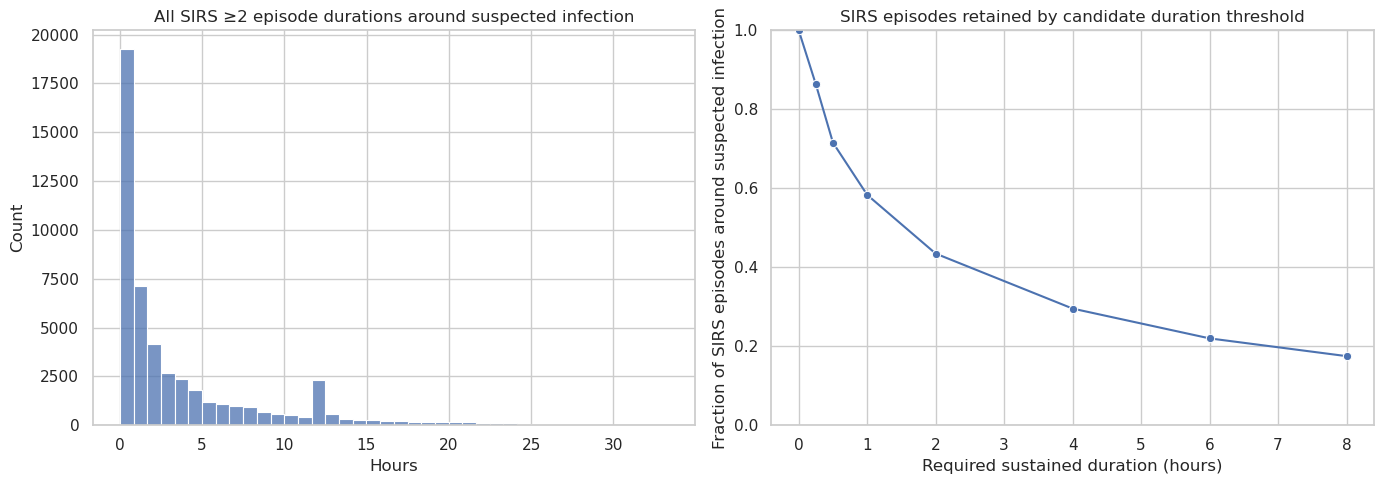

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if episode_duration.height:
    sns.histplot(
        episode_duration.filter(
            (pl.col("full_episode_duration_hours") > pl.col("full_episode_duration_hours").quantile(0.01))&
            (pl.col("full_episode_duration_hours") < pl.col("full_episode_duration_hours").quantile(0.99))
		)
        .to_pandas(),
        x="full_episode_duration_hours",
        bins=40,
        ax=axes[0],
    )
axes[0].set_title("All SIRS ≥2 episode durations around suspected infection")
axes[0].set_xlabel("Hours")

sns.lineplot(
    threshold_retention.to_pandas(),
    x="threshold_hours",
    y="retained_fraction",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("SIRS episodes retained by candidate duration threshold")
axes[1].set_xlabel("Required sustained duration (hours)")
axes[1].set_ylabel("Fraction of SIRS episodes around suspected infection")
axes[1].set_ylim(0, 1)
plt.tight_layout()


## Reference-outcome evaluation

To claim reduced false positives, evaluate thresholds against an encounter-level reference containing exactly one Boolean `reference_positive` value per encounter. Prefer clinician adjudication. Billing status can be analyzed as disagreement, but should not automatically be treated as clinical truth. Choose a threshold on a derivation cohort and report final performance on a separate validation cohort.


In [28]:
def safe_ratio(numerator: int, denominator: int) -> float | None:
    return numerator / denominator if denominator else None


def evaluate_duration_thresholds(
    infection_episodes: pl.DataFrame,
    sirs_episodes: pl.DataFrame,
    reference: pl.DataFrame,
    *,
    reference_positive_col: str = "reference_positive",
    thresholds: list[float] = CANDIDATE_DURATION_HOURS,
) -> pl.DataFrame:
    require_columns(reference, {ENCOUNTER_COL, reference_positive_col}, "reference")
    duplicate_labels = reference.group_by(ENCOUNTER_COL).len().filter(pl.col("len") > 1).height
    if duplicate_labels:
        raise ValueError(f"Reference has {duplicate_labels} encounters with duplicate labels")

    encounter_universe = infection_episodes.select(ENCOUNTER_COL).unique()
    encounter_duration = (
        encounter_universe.join(
            sirs_episodes.group_by(ENCOUNTER_COL).agg(
                pl.col("full_episode_duration_hours").max().alias("maximum_sirs_duration_hours"),
                pl.lit(True).alias("has_sirs_episode"),
            ),
            on=ENCOUNTER_COL,
            how="left",
        )
        .with_columns(
            pl.col("maximum_sirs_duration_hours").fill_null(0.0),
            pl.col("has_sirs_episode").fill_null(False),
        )
    )
    evaluated = encounter_duration.join(
        reference.select(ENCOUNTER_COL, reference_positive_col),
        on=ENCOUNTER_COL,
        how="inner",
    ).with_columns(pl.col(reference_positive_col).cast(pl.Boolean))

    rows = []
    for threshold in thresholds:
        classified = evaluated.with_columns(
            (
                pl.col("has_sirs_episode")
                & (pl.col("maximum_sirs_duration_hours") >= threshold)
            ).alias("predicted_positive")
        )
        counts = classified.select(
            (pl.col("predicted_positive") & pl.col(reference_positive_col)).sum().alias("tp"),
            (pl.col("predicted_positive") & ~pl.col(reference_positive_col)).sum().alias("fp"),
            (~pl.col("predicted_positive") & ~pl.col(reference_positive_col)).sum().alias("tn"),
            (~pl.col("predicted_positive") & pl.col(reference_positive_col)).sum().alias("fn"),
        ).row(0, named=True)
        tp, fp, tn, fn = (int(counts[name]) for name in ("tp", "fp", "tn", "fn"))
        rows.append(
            {
                "threshold_hours": threshold,
                "evaluated_encounters": tp + fp + tn + fn,
                "true_positive": tp,
                "false_positive": fp,
                "true_negative": tn,
                "false_negative": fn,
                "sensitivity": safe_ratio(tp, tp + fn),
                "specificity": safe_ratio(tn, tn + fp),
                "positive_predictive_value": safe_ratio(tp, tp + fp),
                "negative_predictive_value": safe_ratio(tn, tn + fn),
            }
        )
    return pl.DataFrame(rows)


# Example after supplying an approved reference table:
# reference = pl.read_parquet("path/to/deidentified_adjudicated_reference.parquet")
# threshold_performance = evaluate_duration_thresholds(
#     infection_anchors, sirs_episodes_around_infection, reference
# )
# threshold_performance


## Reporting checklist

Before proposing a duration cutoff, report: anchor policy; association window; number of unique SIRS ≥2 episodes around infection; number deduplicated across multiple infection windows; retention at every candidate threshold; sensitivity, PPV, specificity, and NPV against the approved reference; and results separately for POA/NPOA definitions. Do not export `sirs_episodes_around_infection`, `infection_duration_summary`, or `episode_overlaps`, because they contain encounter identifiers.
